# Fast Fourier transform

## "By hand" DFT vs FFT

The Discrete Fourier transform is:

$$
c_k = \sum_{n=0}^{N-1}y_n e^{-i2\pi kn/N}
$$

The method we have used so far ($c_k$ in the code below) has a complexity of $O(N^2)$. The fast Fourier transform algorithm found in scipy and numpy are optimized to be $O(N\log(N))$. We can check the speed difference below:

By hand DFT took 0.008736610412597656 s. The FFT took 9.751319885253906e-05 s.
By hand DFT took 0.17478156089782715 s. The FFT took 7.343292236328125e-05 s.
By hand DFT took 0.6876852512359619 s. The FFT took 7.891654968261719e-05 s.
By hand DFT took 1.4973313808441162 s. The FFT took 7.724761962890625e-05 s.
By hand DFT took 2.4152283668518066 s. The FFT took 7.82012939453125e-05 s.
By hand DFT took 3.8320388793945312 s. The FFT took 8.368492126464844e-05 s.


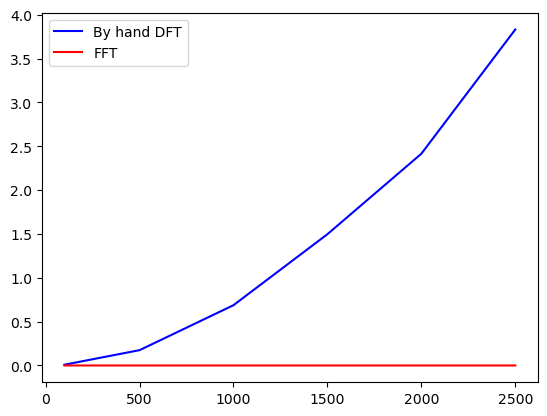

In [10]:
import numpy as np
import scipy as sp 
import matplotlib.pyplot as plt 
import time

N = [100, 500, 1000, 1500, 2000, 2500]

def test_func(t):
    return np.sin(t)

def ck(y, N):
    c = np.zeros(N, dtype='complex')
    for i in range(N):
        for j in range(N):
            c[i] += y[j]*np.exp(-1j*2*np.pi*i*j/N)
    return c

t_dft = np.zeros(len(N))
t_fft = np.zeros(len(N))

for i, n in enumerate(N):
    t = np.linspace(0, 2*np.pi, num=n)
    yn = test_func(t)

    start_time = time.time()
    c = ck(yn, n)
    stop_time = time.time()
    t_dft[i] = stop_time - start_time 

    start_time = time.time()
    c = sp.fft.fft(yn)
    stop_time = time.time()

    t_fft[i] = stop_time - start_time

    print(f"By hand DFT took {t_dft[i]} s. The FFT took {t_fft[i]} s.")

fig, axes = plt.subplots(1, 1)
axes.plot(N, t_dft, 'b', label="By hand DFT")
axes.plot(N, t_fft, 'r', label="FFT")
axes.legend(loc='upper left')

plt.show()

## scipy vs numpy

Both scipy and numpy have FFT algorithms built-in. However, the scipy functions are faster, as shown below.

numpy took 0.008001089096069336 s. scipy took 0.00015282630920410156 s.
numpy took 0.00012755393981933594 s. scipy took 9.72747802734375e-05 s.
numpy took 0.0013377666473388672 s. scipy took 0.0008993148803710938 s.
numpy took 0.03517651557922363 s. scipy took 0.017433643341064453 s.
numpy took 0.3965764045715332 s. scipy took 0.23795723915100098 s.
numpy took 4.13585638999939 s. scipy took 2.2289090156555176 s.


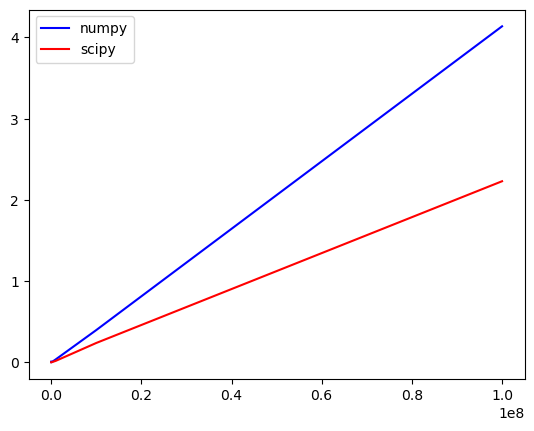

In [15]:
N = [1000, 10000, 100000, 1000000, 10000000, 100000000]

t_np = np.zeros(len(N))
t_sp = np.zeros(len(N))

for i, n in enumerate(N):
    t = np.linspace(0, 2*np.pi, num=n)
    yn = test_func(t)

    start_time = time.time()
    c = np.fft.fft(yn)
    stop_time = time.time()
    t_np[i] = stop_time - start_time 

    start_time = time.time()
    c = sp.fft.fft(yn)
    stop_time = time.time()

    t_sp[i] = stop_time - start_time

    print(f"numpy took {t_np[i]} s. scipy took {t_sp[i]} s.")

fig, axes = plt.subplots(1, 1)
axes.plot(N, t_np, 'b', label="numpy")
axes.plot(N, t_sp, 'r', label="scipy")
axes.legend(loc='upper left')

plt.show()

## fft vs rfft

The *rfft* algorithm should be used when the input is real. It is faster than the *fft* algorithm and should be used when modeling real functions.

rfft took 0.004969596862792969 s. fft took 0.000125885009765625 s.
rfft took 8.273124694824219e-05 s. fft took 9.584426879882812e-05 s.
rfft took 0.0006270408630371094 s. fft took 0.0007698535919189453 s.
rfft took 0.018328189849853516 s. fft took 0.018364906311035156 s.
rfft took 0.2164762020111084 s. fft took 0.23060035705566406 s.
rfft took 2.1554417610168457 s. fft took 2.289443254470825 s.


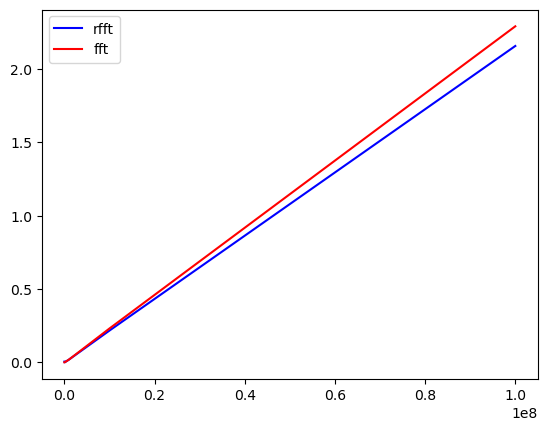

In [17]:
N = [1000, 10000, 100000, 1000000, 10000000, 100000000]

t_fft = np.zeros(len(N))
t_rfft = np.zeros(len(N))

for i, n in enumerate(N):
    t = np.linspace(0, 2*np.pi, num=n)
    yn = test_func(t)

    start_time = time.time()
    c = sp.fft.rfft(yn)
    stop_time = time.time()
    t_rfft[i] = stop_time - start_time 

    start_time = time.time()
    c = sp.fft.fft(yn)
    stop_time = time.time()

    t_fft[i] = stop_time - start_time

    print(f"rfft took {t_rfft[i]} s. fft took {t_fft[i]} s.")

fig, axes = plt.subplots(1, 1)
axes.plot(N, t_rfft, 'b', label="rfft")
axes.plot(N, t_fft, 'r', label="fft")
axes.legend(loc='upper left')

plt.show()


## Example: 1D

Consider a pulse of light from a laser propagating in the $z$ direction. Light is a wave that we represent with a trigonometric function. 
We add a Gaussian envelope, the width of which determines the time duration of the light pulse. 

$$
E(z, t) = E_0 e^{-(t-z/c)^2/\tau^2} cos(kz-\omega t + \phi_0)
$$

where $c$ is the speed of light, $\tau$ is related to the pulse duration, $k$ is the wavenumber, 
and $\omega$ is the angular frequency. 

For example, a 25 fs ultrafast pulse centered at 800 nm (red) has the following constants:
- $k = 2\pi/\lambda = 2\pi/(800\times10^{-9}) = 7.854\times10^6$ m$^{-1}$.
- $\omega = ck = 2.356\times10^15$ rad/s.
- $\tau = 30$ fs

We plot the electric field at $z = 0$ and $\phi_0 = 0$ below.

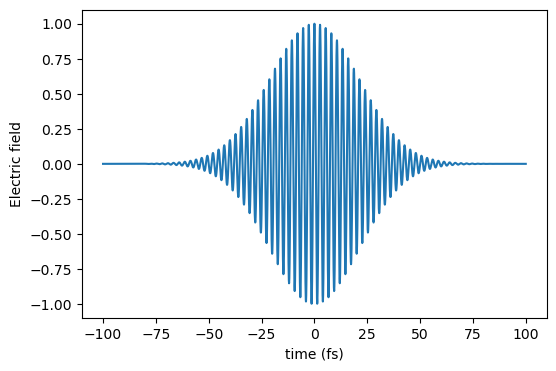

In [40]:
import numpy as np 
import matplotlib.pyplot as plt 

N = 10000
tau = 30e-15
omega = 2.356e15

def e_field(time):
    return np.exp(-time**2/tau**2)*np.cos(-omega*time)

time = np.linspace(-100e-15, 100e-15, num = N)

fig, axes = plt.subplots(1,1, figsize=(6,4))
axes.plot(time*1e15, e_field(time))
axes.set_xlabel("time (fs)")
axes.set_ylabel("Electric field")

plt.show()

The electric field is oscillating rapidly within the pulse. 

If we take a Fourier transform, we expect to see a signal with some components related to the rapid oscillation 
frequency. Remembering that $f = \omega/2\pi$, there should be a peak/feature around $f = 2.356\times10^{15}/2\pi = 3.75\times10^{14}$ Hz.

Let's check.

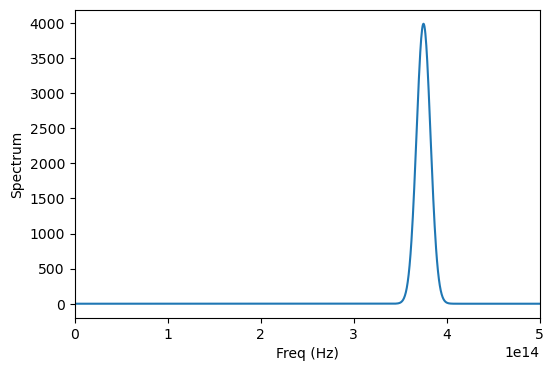

In [48]:
N = 300000
time = np.linspace(-1000e-15, 1000e-15, num = N) # Increase the size of the time array for higher resolution in frequency.

field_time = e_field(time)
field_freq = sp.fft.rfft(field_time)
freq = sp.fft.rfftfreq(N,time[1]-time[0])

fig, axes = plt.subplots(1, 1, figsize=[6,4])
axes.plot(freq, np.abs(field_freq))
axes.set_xlim(0, 5e14)
axes.set_xlabel("Freq (Hz)")
axes.set_ylabel("Spectrum")

plt.show()

The spectrum looks light another Gaussian centered around $3.75\times10^{14}$. It is not too difficult to calculate the Fourier transform of the laser pulse 
analytically. This is what we would find.

## Example: 2D

Fourier transforms can be done in multiple dimension. A 2D transform is a common tool to analyze images. 

Look at the brick wall below. There are clear patterns in the image. In the horizontal direction, the brick has 
a certain frequency approximately equal to the 1/width of each brick. In the vertical direction, the frequency is 
1/height of each brick. Since the height is less than the width, the vertical spatial frequency is higher. 

In the image of the Fourier transform, we see that the vertical frequencies are higher than the horizontal ones.

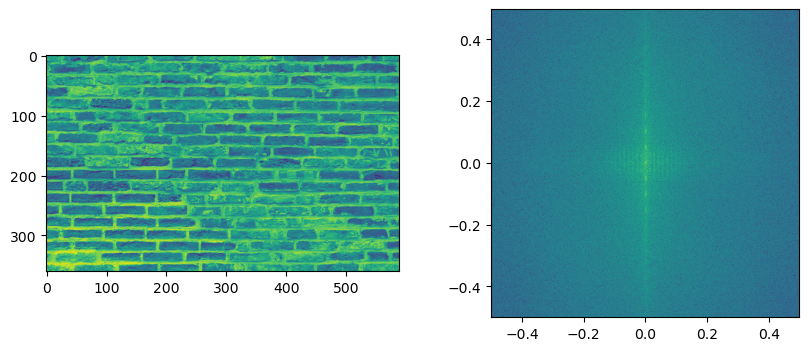

In [49]:
import cv2 

img = cv2.imread("./brick_wall.jpg", 0)

img_k = sp.fft.fftshift(sp.fft.fft2(img))

fx = sp.fft.fftshift(sp.fft.fftfreq(img_k.shape[1]))
fy = sp.fft.fftshift(sp.fft.fftfreq(img_k.shape[0]))

fig, axes = plt.subplots(1,2, figsize=(10,4))

axes[0].imshow(img)
axes[1].imshow(np.log(np.abs(img_k)), origin='lower', extent=[fx[0], fx[-1], fy[0], fy[-1]])

plt.show()